In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
os.environ["PATH"] = "/vast/palmer/apps/avx2/software/texlive/20220321-GCC-12.2.0/bin/x86_64-linux:" + os.environ["PATH"]
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{lmodern}",
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
    "figure.figsize": [10, 7],
    "svg.fonttype": "none",
    "image.cmap": "viridis",
})

In [4]:
JAMMED_DATA_DIR = Path("/home/rg2248/project/friction/data/local-friction/thomson/jammed")

In [5]:
def load_data(data_dir):
    files = sorted(
        data_dir.glob("mu-*.npz"),
        key=lambda path: float(path.stem.removeprefix("mu-")),
    )

    return {
        float(path.stem.removeprefix("mu-")): dict(np.load(path))
        for path in files
    }

jammed_data = load_data(JAMMED_DATA_DIR)

mu_eff = np.array(sorted(jammed_data.keys()))
data = jammed_data

In [6]:
for value in mu_eff:
    jammed = jammed_data[value]

    print(
        f"μeff={value:g}  "
        f"All={len(jammed['all'])}  "
        f"SS={len(jammed['ss'])}  "
        f"SL={len(jammed['sl'])}  "
        f"LL={len(jammed['ll'])}"
    )

μeff=0.01  All=4130  SS=805  SL=2091  LL=1234
μeff=0.03  All=4115  SS=823  SL=2034  LL=1258
μeff=0.05  All=5215  SS=1027  SL=2631  LL=1557
μeff=0.1  All=6954  SS=1400  SL=3422  LL=2132
μeff=0.3  All=4445  SS=854  SL=2229  LL=1362
μeff=0.5  All=3355  SS=615  SL=1725  LL=1015
μeff=1  All=5431  SS=1091  SL=2583  LL=1757


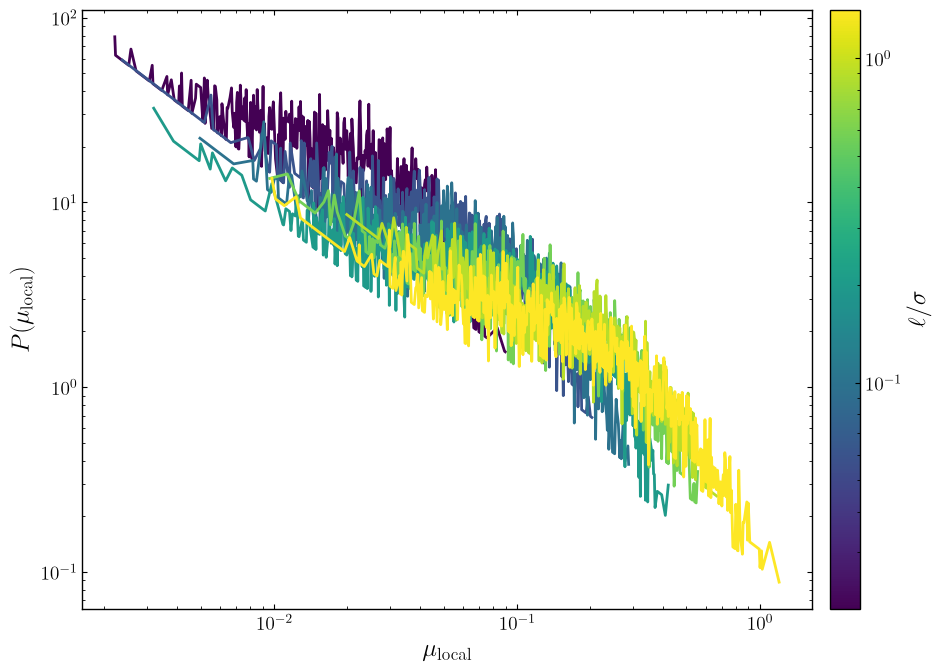

In [7]:
from matplotlib.colors import LogNorm

l_over_sigma = 2 * mu_eff / np.sqrt(1 + mu_eff**2)
min_count = 4

def positive(values):
    return values[np.isfinite(values) & (values > 0)]

positive_values = np.concatenate([
    positive(jammed_data[value]["all"])
    for value in mu_eff
])

bins = np.logspace(
    np.log10(positive_values.min()),
    np.log10(positive_values.max()),
    2000,
)

centers = np.sqrt(bins[:-1] * bins[1:])
norm = LogNorm(l_over_sigma.min(), l_over_sigma.max())
cmap = plt.get_cmap("viridis")

def density(values):
    values = positive(values)
    counts, _ = np.histogram(values, bins=bins)
    probability = counts / (len(values) * np.diff(bins))
    return probability, counts

fig, ax = plt.subplots()

for value, ratio in zip(mu_eff, l_over_sigma):
    probability, counts = density(jammed_data[value]["all"])
    mask = counts >= min_count

    ax.plot(
        centers[mask],
        probability[mask],
        color=cmap(norm(ratio)),
    )

colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    pad=0.02,
)

colorbar.set_label(r"$\ell/\sigma$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\mu_{\mathrm{local}}$")
ax.set_ylabel(r"$P(\mu_{\mathrm{local}})$")
plt.tight_layout()
plt.savefig("../../figures/friction/thomson/jammed-distributions.png", dpi=600, bbox_inches="tight")
plt.show()